# Graduation Lab (Week 6)

## Instructions:

Let's build a kNN model using the college completion data from last week. 
The data is messy and you have a degrees of freedom problem, as in, we have too many features.  

You've done most of the hard work already, so you should be ready to move forward with building your model. 

1. Use the question/target variable you submitted from last week and build a model to answer the question you created for this dataset. 

2. Build and optimize a kNN model to predict your target variable. Meaning use the tune set to select the correct k value. 

3. Experiment with the threshold function, what happens at higher and lower thresholds. Document what you see in comments. 

4. Evaluate the results using the confusion matrix (at the default threshold). Then talk through your question, summarize what concerns or positive elements do you have about the model? 

Bonus: Adjust the function that selects k to output on Specificity instead of Accuracy

### Example of how I cleaned the data

readme for the dataset - https://data.world/databeats/college-completion/workspace/file?filename=README.txt

In [166]:
import pandas as pd

grad_data = pd.read_csv('https://query.data.world/s/qpi2ltkz23yp2fcaz4jmlrskjx5qnp', encoding="cp1252")
# the encoding part here is important to properly read the data! It doesn't apply to ALL csv files read from the web,
# but it was necessary here.
grad_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 62 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   unitid                                3798 non-null   int64  
 1   chronname                             3798 non-null   object 
 2   city                                  3798 non-null   object 
 3   state                                 3798 non-null   object 
 4   level                                 3798 non-null   object 
 5   control                               3798 non-null   object 
 6   basic                                 3798 non-null   object 
 7   hbcu                                  94 non-null     object 
 8   flagship                              50 non-null     object 
 9   long_x                                3798 non-null   float64
 10  lat_y                                 3798 non-null   float64
 11  site             

In [167]:
grad_data.shape

(3798, 62)

In [168]:
# We have a lot of data! A lot of these have many missing values or are otherwise not useful.

to_drop = list(range(39, 56))
to_drop.extend([27, 9, 10, 11, 28, 36, 60, 56])

In [169]:
grad_data1 = grad_data.drop(grad_data.columns[to_drop], axis=1)
grad_data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   unitid                  3798 non-null   int64  
 1   chronname               3798 non-null   object 
 2   city                    3798 non-null   object 
 3   state                   3798 non-null   object 
 4   level                   3798 non-null   object 
 5   control                 3798 non-null   object 
 6   basic                   3798 non-null   object 
 7   hbcu                    94 non-null     object 
 8   flagship                50 non-null     object 
 9   student_count           3798 non-null   int64  
 10  awards_per_value        3798 non-null   float64
 11  awards_per_state_value  3798 non-null   float64
 12  awards_per_natl_value   3798 non-null   float64
 13  exp_award_value         3798 non-null   int64  
 14  exp_award_state_value   3798 non-null   

In [170]:
# drop even more data that doesn't look predictive
drop_more = [0,2,3,6,8,11,12,14,15,18,21,23,29,32,33,34,35]
grad_data2 = grad_data1.drop(grad_data1.columns[drop_more], axis=1)
grad_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   chronname             3798 non-null   object 
 1   level                 3798 non-null   object 
 2   control               3798 non-null   object 
 3   hbcu                  94 non-null     object 
 4   student_count         3798 non-null   int64  
 5   awards_per_value      3798 non-null   float64
 6   exp_award_value       3798 non-null   int64  
 7   exp_award_percentile  3798 non-null   int64  
 8   ft_pct                3794 non-null   float64
 9   fte_percentile        3798 non-null   int64  
 10  med_sat_value         1337 non-null   float64
 11  aid_value             3797 non-null   float64
 12  grad_100_value        3467 non-null   float64
 13  grad_100_percentile   3467 non-null   float64
 14  grad_150_value        3467 non-null   float64
 15  grad_150_percentile  

In [171]:
grad_data2.head()

,chronname,level,control,hbcu,student_count,awards_per_value,exp_award_value,exp_award_percentile,ft_pct,fte_percentile,med_sat_value,aid_value,grad_100_value,grad_100_percentile,grad_150_value,grad_150_percentile,pell_value,retain_value,ft_fac_value,cohort_size
0,Alabama A&M University,4-year,Public,X,4051,14.2,105331,90,93.8,33,823.0,7142.0,10.0,15.0,29.1,14.0,71.2,63.1,82.8,882.0
1,University of Alabama at Birmingham,4-year,Public,NaN,11502,20.9,136546,97,72.7,67,1146.0,6088.0,29.4,67.0,53.5,66.0,35.1,80.2,92.4,1376.0
2,Amridge University,4-year,Private not-for-profit,NaN,322,29.9,58414,30,62.7,12,NaN,2540.0,0.0,0.0,66.7,72.0,68.4,37.5,67.2,3.0
3,University of Alabama at Huntsville,4-year,Public,NaN,5696,20.9,64418,61,74.4,40,1180.0,6647.0,16.5,34.0,48.4,54.0,32.8,81.0,65.5,759.0
4,Alabama State University,4-year,Public,X,5356,11.6,132407,96,91.0,41,830.0,7256.0,8.8,11.0,25.2,9.0,82.7,62.2,67.0,1351.0


In [172]:
import numpy as np
grad_data2.replace('NULL', np.nan, inplace=True)

In [173]:
grad_data2['hbcu'] = [1 if grad_data2['hbcu'][i]=='X' else 0 for i in range(len(grad_data2['hbcu']))]
grad_data2['hbcu'].value_counts()

hbcu
0    3704
1      94
Name: count, dtype: int64

In [174]:
grad_data2['hbcu'] = grad_data2.hbcu.astype('category')

In [175]:
# convert more variables to factors
grad_data2[['level', 'control']] = grad_data2[['level', 'control']].astype('category')

In [176]:
# In R, we convert vals to numbers, but they already are in this import
grad_data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   chronname             3798 non-null   object  
 1   level                 3798 non-null   category
 2   control               3798 non-null   category
 3   hbcu                  3798 non-null   category
 4   student_count         3798 non-null   int64   
 5   awards_per_value      3798 non-null   float64 
 6   exp_award_value       3798 non-null   int64   
 7   exp_award_percentile  3798 non-null   int64   
 8   ft_pct                3794 non-null   float64 
 9   fte_percentile        3798 non-null   int64   
 10  med_sat_value         1337 non-null   float64 
 11  aid_value             3797 non-null   float64 
 12  grad_100_value        3467 non-null   float64 
 13  grad_100_percentile   3467 non-null   float64 
 14  grad_150_value        3467 non-null   float64 
 15  grad

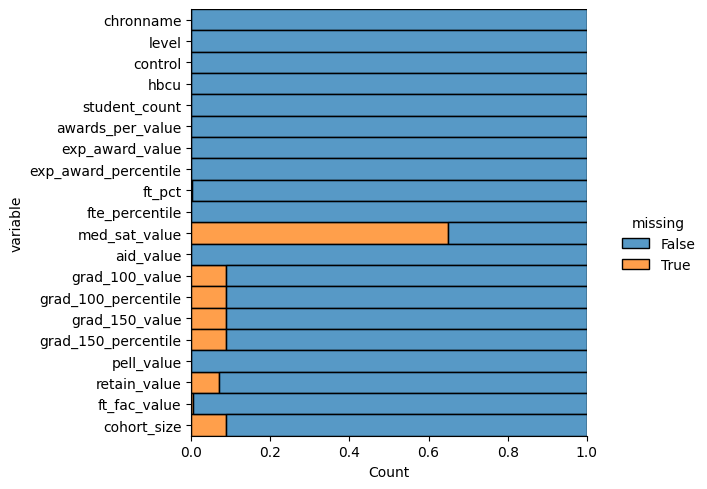

In [177]:
# check missing data
import seaborn as sns

sns.displot(
    data=grad_data2.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)

In [178]:
#let's drop med_stat_value then delete the rest of the NA rows
grad_data2 = grad_data2.drop(grad_data[['med_sat_value']], axis=1)
grad_data2.dropna(axis = 0, how = 'any', inplace = True)

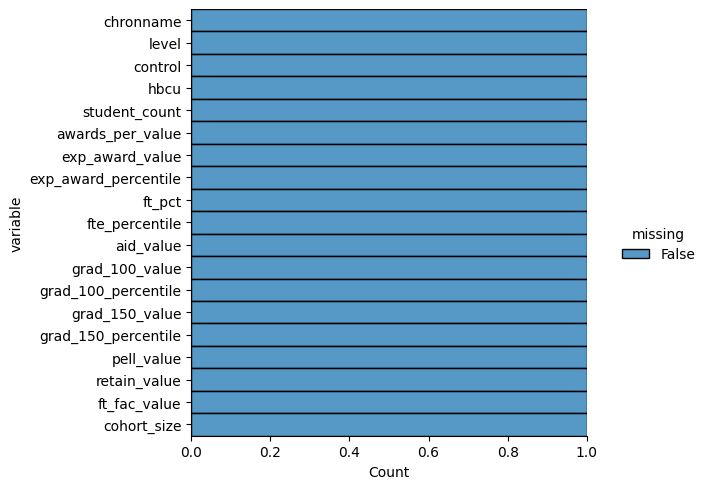

In [179]:
sns.displot(
    data=grad_data2.isna().melt(value_name="missing"),
    y="variable",
    hue="missing",
    multiple="fill",
    aspect=1.25
)

# Set the target variable

In [180]:
median_grad = grad_data2["grad_100_value"].median()
grad_data2["grad_100_class"] = (grad_data2["grad_100_value"] >= median_grad).astype('category')
#grad_data2.drop(columns=['grad_100_value'], inplace=True)
#grad_data2['grad_100_class_1'] = (grad_data2['grad_100_value'] >= median_grad).astype(int)
#grad_data2['grad_100_class_0'] = (grad_data2['grad_100_value'] < median_grad).astype(int)

# Build and optimize a kNN model to predict your target variable.

In [181]:
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler()
numeric_cols = grad_data2.select_dtypes(include='int64').columns
d = scaler.fit_transform(grad_data2[numeric_cols])   # conduct data transformation
scaled_df = pd.DataFrame(d, columns=numeric_cols)   # convert back to pd df; transformation converts to array
grad_data2[numeric_cols] = scaled_df

# One-hot encoding

In [182]:
# One-hot encoding
grad_data2['chronname']=grad_data2['chronname'].astype('category')
cat_cols = grad_data2.select_dtypes(include='category').columns
encoded = pd.get_dummies(grad_data2[cat_cols], drop_first=True)
grad_data2 = grad_data2.drop(cat_cols, axis=1)
grad_data2 = grad_data2.join(encoded)
grad_data2.dropna(axis = 0, how = 'any', inplace = True)
print(grad_data2)

      student_count  awards_per_value  exp_award_value  exp_award_percentile  \
0          0.023677              14.2         0.019941                  0.90   
1          0.067476              20.9         0.025851                  0.97   
2          0.001758              29.9         0.011059                  0.30   
3          0.033347              20.9         0.012196                  0.61   
4          0.031348              11.6         0.025067                  0.96   
...             ...               ...              ...                   ...   
3365       0.002134              46.1         0.011082                  0.91   
3366       0.000488              13.0         0.023993                  0.99   
3367       0.000511              25.2         0.004553                  0.03   
3368       0.000688              22.7         0.020061                  0.72   
3369       0.002733              22.5         0.010022                  0.63   

      ft_pct  fte_percentile  aid_value

# Estimation

In [184]:
print(grad_data2['grad_100_class_True'].value_counts()[1] / grad_data2['grad_100_class_True'].count())
#This means that at random, we have an 50% chance of correctly predicting whether a person graduates within the normal time.

0.4949724294518326


/tmp/ipykernel_1373/2492026163.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(grad_data2['grad_100_class_True'].value_counts()[1] / grad_data2['grad_100_class_True'].count())


In [154]:
print(grad_data2['grad_100_class_True'].value_counts()[1] / grad_data2['grad_100_class_True'].count())
#This means that at random, we have an 50% chance of correctly predicting whether a person graduates within the normal time.

0.4949724294518326


/tmp/ipykernel_1373/2492026163.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(grad_data2['grad_100_class_True'].value_counts()[1] / grad_data2['grad_100_class_True'].count())


# Train/test split

In [193]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(grad_data2,  test_size=0.4, stratify = grad_data2['grad_100_class_True']) 
test, val = train_test_split(test, test_size=0.5, stratify=test['grad_100_class_True'])

import random
from sklearn.neighbors import KNeighborsClassifier
random.seed(11)  

X_train = train.drop(['grad_100_class_True'], axis=1)
y_train = train['grad_100_class_True'].values

neigh = KNeighborsClassifier(n_neighbors=9)
neigh.fit(X_train, y_train)

# Measure accuracy on the training data
X_train = train.drop(['grad_100_class_True'], axis=1)
y_train = train['grad_100_class_True'].values

train_accuracy = neigh.score(X_train, y_train)
print(f"Training Accuracy: {train_accuracy}")

Training Accuracy: 0.826392644672796


In [194]:
X_val = val.drop(['grad_100_class_True'], axis=1)
y_val = val['grad_100_class_True'].values

print(neigh.score(X_val, y_val))

0.7633711507293355


In [195]:
X_test = test.drop(['grad_100_class_True'], axis=1).values
y_test = test['grad_100_class_True'].values

In [196]:
y_val_pred = neigh.predict(X_val)

In [197]:
from sklearn.metrics import accuracy_score

test_probs = neigh.predict_proba(X_test)
test_preds = neigh.predict(X_test)
test_probabilities = pd.DataFrame(test_probs, columns = ['grad_100_class_False','grad_100_class_True'])
final_model = pd.DataFrame({'actual_class': y_test.tolist(),
                           'pred_class': test_preds.tolist(),
                           'pred_prob': test_probabilities['grad_100_class_True']})
final_model.head()

/workspaces/DS-3021/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/workspaces/DS-3021/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


,actual_class,pred_class,pred_prob
0,True,True,0.666667
1,False,False,0.111111
2,True,True,1.000000
3,False,False,0.222222
4,False,False,0.333333


In [198]:
from sklearn.metrics import classification_report

print(classification_report(y_val_pred, y_val))

              precision    recall  f1-score   support

       False       0.79      0.75      0.77       322
        True       0.74      0.78      0.76       295

    accuracy                           0.76       617
   macro avg       0.76      0.76      0.76       617
weighted avg       0.76      0.76      0.76       617



In [199]:
from sklearn.model_selection import cross_val_score

def chooseK(k, X_train, y_train):
    print("calculating... ", k, "k")
    class_knn = KNeighborsClassifier(n_neighbors=k)
    
    # Use cross-validation to calculate accuracy
    scores = cross_val_score(class_knn, X_train, y_train, cv=5, scoring='accuracy')
    return scores.mean()

test = pd.DataFrame({'k': list(range(1, 22, 2)), 
                     'accu': [chooseK(i, X_train, y_train) for i in list(range(1, 22, 2))]})
print(test)

calculating...  1 k
calculating...  3 k
calculating...  5 k
calculating...  7 k
calculating...  9 k
calculating...  11 k
calculating...  13 k
calculating...  15 k
calculating...  17 k
calculating...  19 k
calculating...  21 k
     k      accu
0    1  0.772853
1    3  0.775012
2    5  0.767442
3    7  0.769065
4    9  0.769071
5   11  0.765816
6   13  0.758236
7   15  0.753916
8   17  0.757160
9   19  0.758239
10  21  0.759864


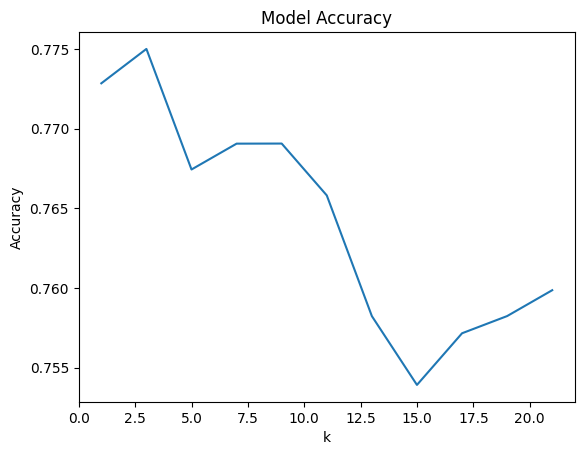

In [200]:
from matplotlib import pyplot as plt
plt.plot(test['k'], test['accu'])
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

3. Experiment with the threshold function, what happens at higher and lower thresholds. Document what you see in comments. 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Predict probabilities on the test set
y_proba = neigh.predict_proba(X_test)[:, 1]

# Define different threshold values for experimentation
thresholds = [0.3, 0.5, 0.7]

# Loop through different thresholds and analyze their effects
for thresh in thresholds:
    # Convert probabilities to binary predictions based on the threshold
    y_pred = (y_proba >= thresh).astype(int)
    
    # Print threshold value
    print(f"\nThreshold: {thresh}")
    
    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)
    
    # Compute classification report (precision, recall, F1-score)
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Document the effects of different thresholds
    if thresh == 0.3:
        print("# Lower threshold (0.3): Increases True Positives but also increases False Positives.")
        print("# The model is more sensitive and predicts more students as graduates, even if they might not be.")
    elif thresh == 0.5:
        print("# Default threshold (0.5): Balances True Positives and False Positives.")
        print("# This is the standard setting used in classification problems.")
    elif thresh == 0.7:
        print("# Higher threshold (0.7): Increases True Negatives but also increases False Negatives.")
        print("# The model is more conservative, predicting fewer students as graduates, leading to more missed true graduates.")



Threshold: 0.3
Confusion Matrix:
 [[170 135]
 [ 31 281]]
Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.56      0.67       305
        True       0.68      0.90      0.77       312

    accuracy                           0.73       617
   macro avg       0.76      0.73      0.72       617
weighted avg       0.76      0.73      0.72       617

# Lower threshold (0.3): Increases True Positives but also increases False Positives.
# The model is more sensitive and predicts more students as graduates, even if they might not be.

Threshold: 0.5
Confusion Matrix:
 [[247  58]
 [ 76 236]]
Classification Report:
               precision    recall  f1-score   support

       False       0.76      0.81      0.79       305
        True       0.80      0.76      0.78       312

    accuracy                           0.78       617
   macro avg       0.78      0.78      0.78       617
weighted avg       0.78      0.78      0.78       617

/workspaces/DS-3021/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


4. Evaluate the results using the confusion matrix (at the default threshold). Then talk through your question, summarize what concerns or positive elements do you have about the model? 

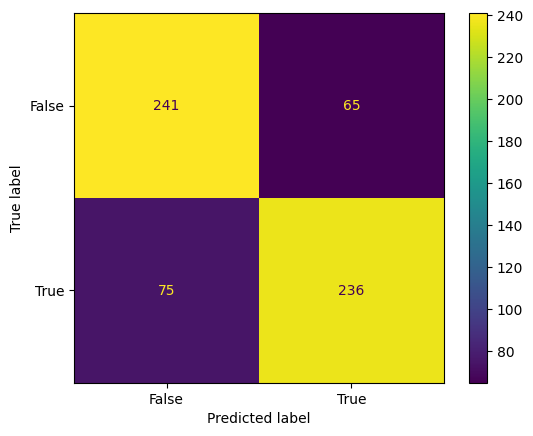

In [163]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

cm = confusion_matrix(y_val,y_val_pred, labels=neigh.classes_)
disp=ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=neigh.classes_)  
disp.plot()
plt.show()